In [16]:
import sys
import os
base_dir = os.path.dirname(__file__) if '__file__' in globals() else os.getcwd()
sys.path.append(os.path.abspath(os.path.join(base_dir, '..')))
import argparse
from utils import *
from tqdm import tqdm
from torch import optim
from model import my_model
import torch.nn.functional as F
import pandas as pd
from utils import get_logger
import scanpy as sc
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
import os
import scipy.sparse as sparse
import anndata
import seaborn as sns
import time
sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3 
sns.set_style("white")
np.random.seed(0)

scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.23.5 scipy==1.13.1 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [10]:
section_id = "151675"
input_dir = os.path.join('..\\Data\\', section_id)
adata = sc.read_visium(path=input_dir, count_file=section_id + '_filtered_feature_bc_matrix.h5')
adata.var_names_make_unique()
sc.pp.calculate_qc_metrics(adata, inplace=True)
adata = adata[:, adata.var['total_counts'] > 100]
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=3000)
hvg_filter = adata.var['highly_variable']
sc.pp.normalize_total(adata, inplace=True)
adata = adata[:, hvg_filter]  
cluster_num =7
gnnlayers = 3
lr = 1e-3
dims = [200]
epochs=400
sigma=0.01
Ann_df = pd.read_csv(os.path.join('..\\Data', section_id, section_id+'_truth.txt'), sep='\t', header=None, index_col=0)
Ann_df.columns = ['Ground Truth']
adata.obs['Ground Truth'] = Ann_df.loc[adata.obs_names, 'Ground Truth']

reading ..\Data\151675\151675_filtered_feature_bc_matrix.h5
 (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)


In [11]:
from image_feature import ImageFeature, image_crop
from pathlib import Path
save_path = 'results'
save_path_image_crop = Path(os.path.join(save_path, 'image_crop', f'{section_id}'))
save_path_image_crop.mkdir(parents=True, exist_ok=True)
adata = image_crop(adata, crop_size=112, save_path=save_path_image_crop, verbose=False)
adata = ImageFeature(adata, pca_components=200, verbose=True, seeds=2023).extract_image_features()
adata

Tiling Image: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ [ time left: 00:00 ]
Extract image feature: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████ [ time left: 00:00 ]


The image feature is added to adata.obsm['Image_Feature']
The pca result of image features is added to adata.obsm['image_feat_pca']


AnnData object with n_obs × n_vars = 3592 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'Ground Truth', 'image_col', 'image_row', 'slice_path'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg'
    obsm: 'spatial', 'image_feature', 'aug_image_feature1', 'aug_image_feature2', 'image_feat_pca'

In [12]:
from sklearn.metrics import pairwise_distances
morphological_similarity = 1 - pairwise_distances(np.array(adata.obsm['image_feat_pca']), metric='cosine')
morphological_similarity[morphological_similarity < 0] = 0

In [13]:
n_spot = len(adata.obs['Ground Truth'] )
n_neighbor = 8
from sklearn.metrics import pairwise_distances
from sklearn.cluster import SpectralClustering
morphological_similarity = 1 - pairwise_distances(np.array(adata.obsm['image_feat_pca']), metric='cosine')
morphological_network = np.zeros((n_spot, n_spot))
for i in range(n_spot):
    vec = morphological_similarity[i, :]
    distance = vec.argsort()[:: -1]
    for t in range(n_neighbor + 1):
        y = distance[t]
        morphological_network[i, y] = morphological_similarity[i, y]

In [14]:
enhanced_adata, cell_spatial = mnmst.data_enhance(adata, k_nei=6, ratio=0.2)
feat = np.array(enhanced_adata.X)
adj = cell_spatial.A
true_labels = pd.Categorical(adata.obs['Ground Truth']).codes


Median distance to closest cell = 138.00362314084367
num_nbrs: 3000


In [18]:
# model.py Line15: out2 = F.normalize(out2, dim=1, p=2) + torch.normal(0, torch.ones_like(out2) * sigma).cpu()
features = feat
adj = sp.csr_matrix(adj)
adj = adj - sp.dia_matrix((adj.diagonal()[np.newaxis, :], [0]), shape=adj.shape)
adj.eliminate_zeros()
print('Laplacian Smoothing...')
adj_norm_s = preprocess_graph(adj, gnnlayers, norm='sym', renorm=True)
sm_fea_s = features
for a in adj_norm_s:
    sm_fea_s = a.dot(sm_fea_s)
sm_fea_s = torch.FloatTensor(sm_fea_s)
adj_1st = (adj + sp.eye(adj.shape[0])).toarray()
acc_list = []
nmi_list = []
ari_list = []
f1_list = []
best_acc=0
best_nmi=0
best_ari=0
best_f1=0
device= 'cpu'
logger = get_logger()
for seed in range(1):
    setup_seed(seed)
    best_accs, best_nmis, best_aris, best_f1s, prediect_labels = clustering(sm_fea_s, true_labels, cluster_num)
    print(best_ari)
    model = my_model([features.shape[1]] + dims)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model = model.to(device)
    inx = sm_fea_s.to(device)
    target = torch.FloatTensor(adj_1st).to(device)
    criterion = torch.nn.MSELoss(reduction='sum')

    print('Start Training...')
    logger.info('--------------------Start Training--------------------')
    for epoch in tqdm(range(epochs)):
        model.train()
        z1, z2,decoder_out= model(inx, is_train=True, sigma=sigma)
        S = z1 @ z2.T
        loss = 0.1 * F.mse_loss(S, target) + criterion(decoder_out, inx) 
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            model.eval()
            z1, z2,decoder_out = model(inx, is_train=False, sigma=sigma)
            hidden_emb = (z1 + z2) / 2
            acc, nmi, ari, f1, predict_labels = clustering(hidden_emb, true_labels, cluster_num)
            if ari >= best_ari:
                best_acc = acc
                best_nmi = nmi
                best_ari = ari
                best_f1 = f1
                label = predict_labels
                best_h = hidden_emb.detach().numpy()
                df_S = pd.DataFrame(S.detach().numpy())
                df_l = pd.DataFrame(label)
                df_X = pd.DataFrame(decoder_out.detach().numpy())

    logger.info('--------------------Training over--------------------')
    logger.info(
        """ ACC {:.2f} NMI {:.2f} ARI {:.2f} f_score {:.2f} """.format(best_acc, best_nmi, best_ari, best_f1))
    print(best_acc, best_nmi, best_ari, best_f1)
    enhanced_adata.obsm['denoised']=decoder_out.detach().numpy()
    enhanced_adata.obs['MvDST_label']=label.astype(str)
    enhanced_adata.obsm['Latent_feature']=hidden_emb.detach().numpy()
    enhanced_adata.obsm['S']=S.detach().numpy()

Laplacian Smoothing...
<class 'torch.Tensor'>


2025-06-17 22:15:27 - root - INFO: - --------------------Start Training--------------------
2025-06-17 22:15:27 - root - INFO: - --------------------Start Training--------------------
2025-06-17 22:15:27 - root - INFO: - --------------------Start Training--------------------


0
Start Training...


  0%|                                                                                                                                       | 0/400 [00:00<?, ?it/s]

<class 'torch.Tensor'>


...

<class 'torch.Tensor'>


 98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 390/400 [02:39<00:03,  2.64it/s]

<class 'torch.Tensor'>


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [02:44<00:00,  2.44it/s]
2025-06-17 22:18:11 - root - INFO: - --------------------Training over--------------------
2025-06-17 22:18:11 - root - INFO: - --------------------Training over--------------------
2025-06-17 22:18:11 - root - INFO: - --------------------Training over--------------------
2025-06-17 22:18:11 - root - INFO: -  ACC 69.54 NMI 72.52 ARI 62.60 f_score 55.99 
2025-06-17 22:18:11 - root - INFO: -  ACC 69.54 NMI 72.52 ARI 62.60 f_score 55.99 
2025-06-17 22:18:11 - root - INFO: -  ACC 69.54 NMI 72.52 ARI 62.60 f_score 55.99 


69.54 72.52 62.6 55.99


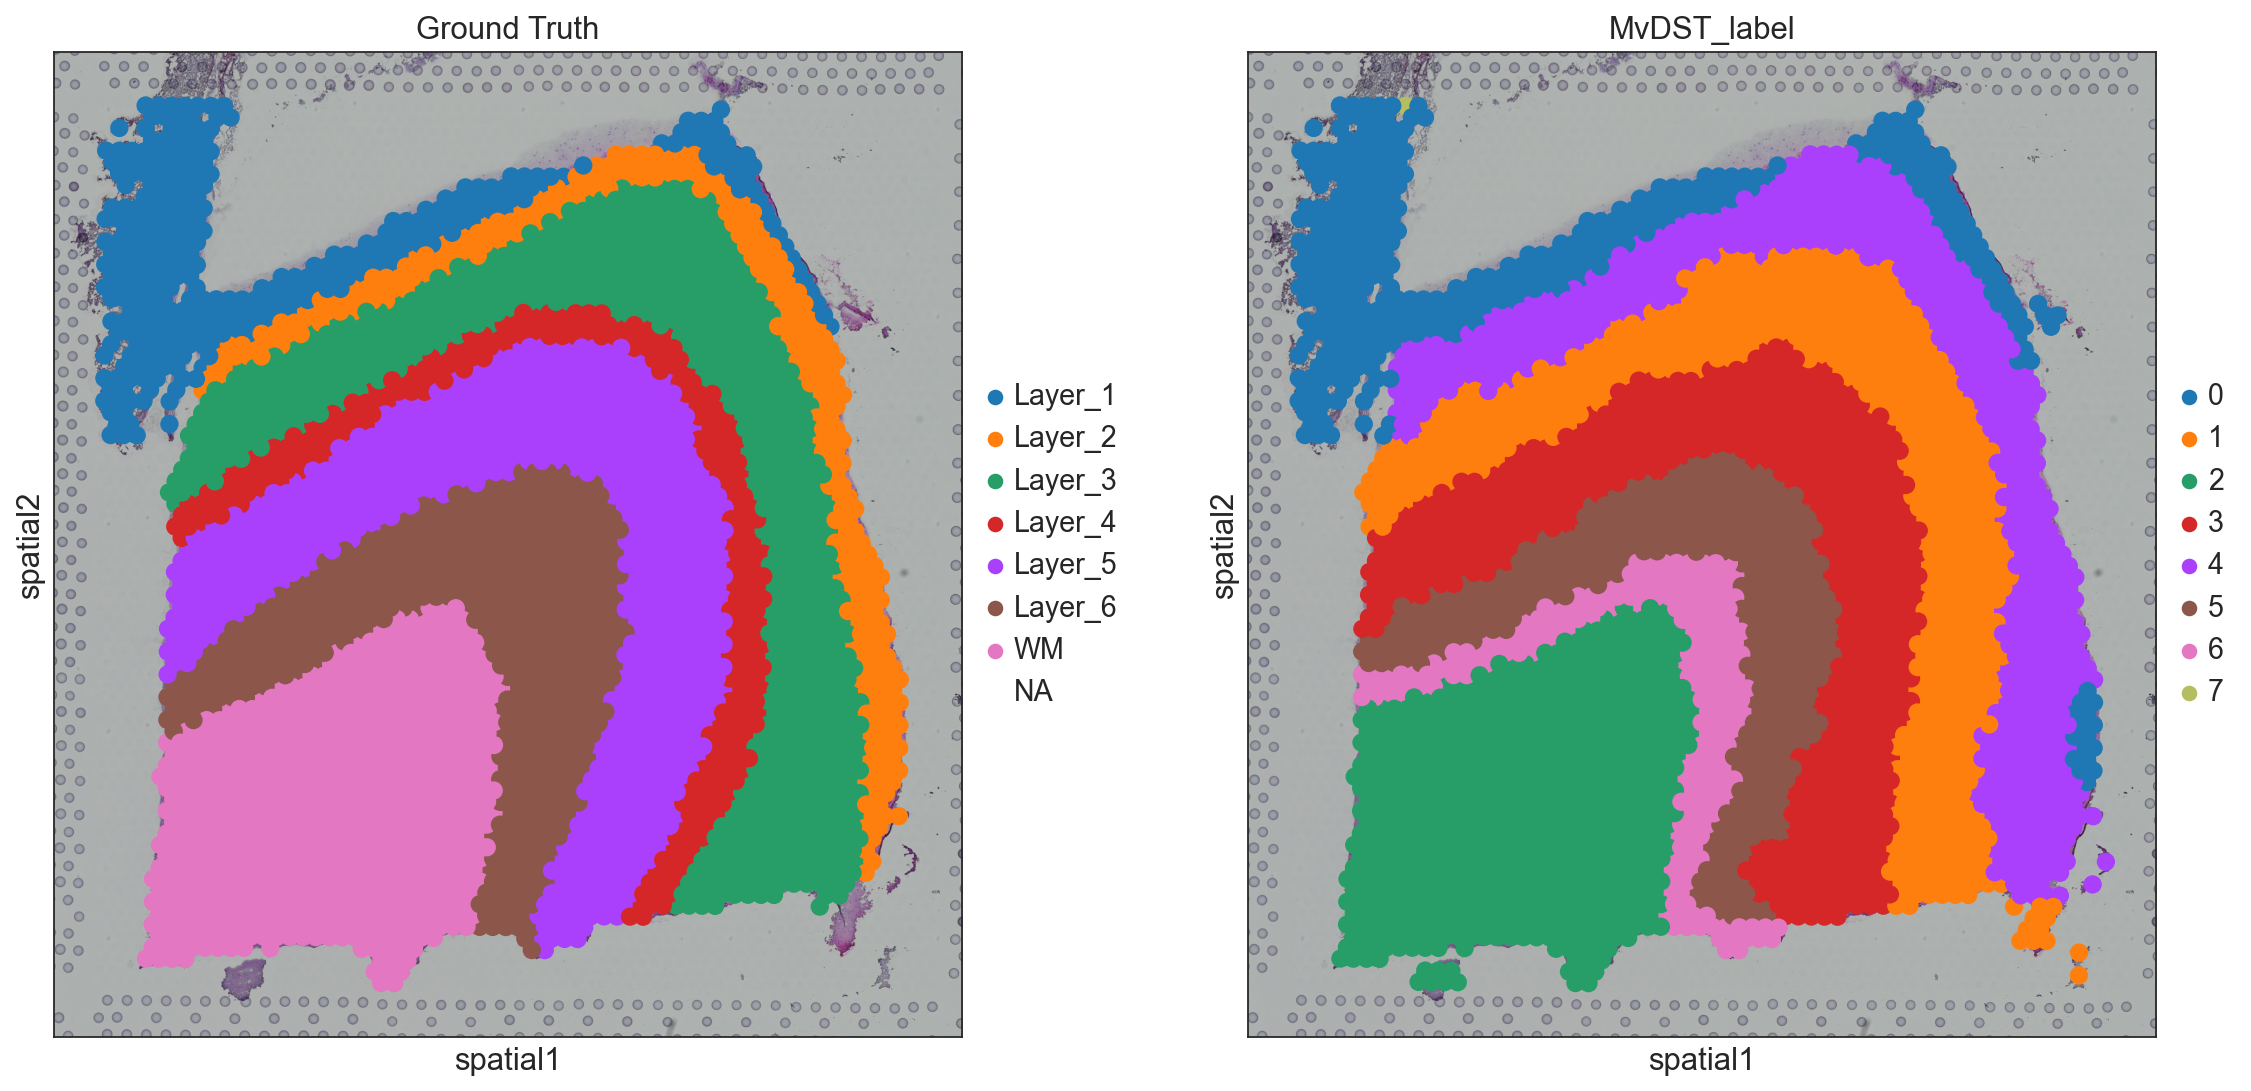

In [22]:
sc.pl.spatial(enhanced_adata, color=['Ground Truth','MvDST_label'], size=2)

In [21]:
ARI = adjusted_rand_score(enhanced_adata.obs['MvDST_label'], pd.Categorical(enhanced_adata.obs['Ground Truth']).codes)
print('Adjusted rand index = %.3f' %ARI)

Adjusted rand index = 0.626
